# Trabajo Aplicado – Series de Tiempo
## Pronóstico del número de graduados del programa de Estadística, sede Bogotá

In [16]:
import os, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import het_arch
from scipy import stats
from arch import arch_model
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# 1. Carga de datos

La variable `period` toma únicamente los valores **1** (enero–junio) y **2** (agosto–diciembre). Se construye la etiqueta `AAAA-S` y se trabaja con un **índice secuencial** para evitar distorsiones por frecuencias trimestrales.

In [17]:
ruta = list(Path('.', 'data').rglob('*.csv'))

data = pd.read_csv(ruta[0], skiprows=1, names=['year', 'period', 'total'])
data['year']   = data['year'].astype(int)
data['period'] = data['period'].astype(int)   # solo 1 o 2
data['total']  = data['total'].astype(float)

data = data.sort_values(['year', 'period']).reset_index(drop=True)
data['periodo'] = data['year'].astype(str) + '-' + data['period'].astype(str)
data.index = pd.RangeIndex(start=0, stop=len(data), name='t')

serie    = data['total']
etiquetas = data['periodo']
data.head()

,year,period,total,periodo
t,,,,
0,2009,1,8.0,2009-1
1,2009,2,13.0,2009-2
2,2010,1,15.0,2010-1
3,2010,2,18.0,2010-2
4,2011,1,27.0,2011-1


In [18]:
print(f'Observaciones: {len(serie)}')
print(f'Periodo: {etiquetas.iloc[0]} -- {etiquetas.iloc[-1]}')
serie.describe()

Observaciones: 34
Periodo: 2009-1 -- 2025-2


count    34.000000
mean     24.264706
std      10.287706
min       2.000000
25%      18.250000
50%      24.500000
75%      30.500000
max      54.000000
Name: total, dtype: float64

# 2. Gráfico de la serie original

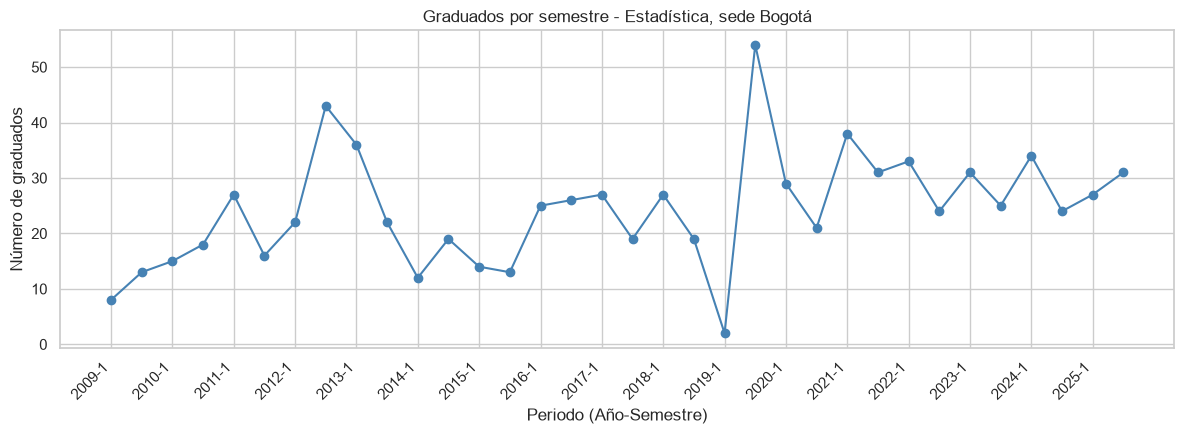

In [19]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(serie.index, serie.values, marker='o', color='steelblue')
ax.set_xticks(serie.index[::2])
ax.set_xticklabels(etiquetas.values[::2], rotation=45, ha='right')
ax.set_title('Graduados por semestre - Estadística, sede Bogotá')
ax.set_xlabel('Periodo (Año-Semestre)')
ax.set_ylabel('Número de graduados')
plt.tight_layout()
plt.savefig('serie_original.png', dpi=150)
plt.show()

# 3. Transformación logarítmica

Lambda óptimo Box-Cox: 0.776
Varianza 1ª mitad: 82.81 | Varianza 2ª mitad: 112.01


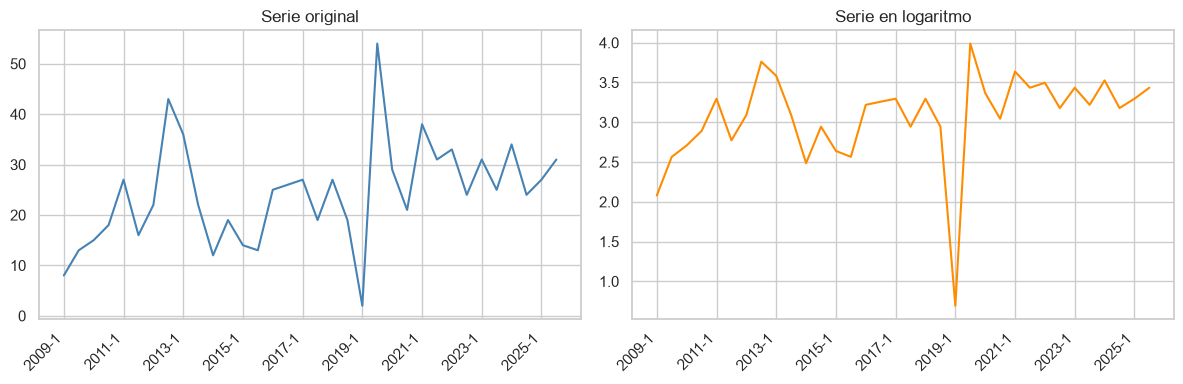

In [20]:
bc_vals, bc_lambda = stats.boxcox(serie.values)
print(f'Lambda óptimo Box-Cox: {bc_lambda:.3f}')

mitad = len(serie) // 2
print(f'Varianza 1ª mitad: {serie.iloc[:mitad].var():.2f} | Varianza 2ª mitad: {serie.iloc[mitad:].var():.2f}')

log_serie = np.log(serie)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(serie.index, serie.values, color='steelblue')
axes[0].set_title('Serie original')
axes[1].plot(log_serie.index, log_serie.values, color='darkorange')
axes[1].set_title('Serie en logaritmo')
for ax in axes:
    ax.set_xticks(serie.index[::4])
    ax.set_xticklabels(etiquetas.values[::4], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('serie_transformada.png', dpi=150)
plt.show()

# 4. Análisis de estacionariedad (ADF y KPSS)

In [21]:
def reporte_estacionariedad(x, nombre):
    adf = adfuller(x.dropna(), autolag='AIC')
    kp  = kpss(x.dropna(), regression='c', nlags='auto')
    print(f'--- {nombre} ---')
    print(f'ADF : estadístico={adf[0]:.4f}, p-valor={adf[1]:.4f}')
    print(f'KPSS: estadístico={kp[0]:.4f}, p-valor={kp[1]:.4f}')
    print()

reporte_estacionariedad(log_serie,           'Log(serie)')
d_log_serie = log_serie.diff().dropna()
reporte_estacionariedad(d_log_serie, 'Δ Log(serie)')

--- Log(serie) ---
ADF : estadístico=-5.6167, p-valor=0.0000
KPSS: estadístico=0.3665, p-valor=0.0916

--- Δ Log(serie) ---
ADF : estadístico=-7.3291, p-valor=0.0000
KPSS: estadístico=0.2387, p-valor=0.1000



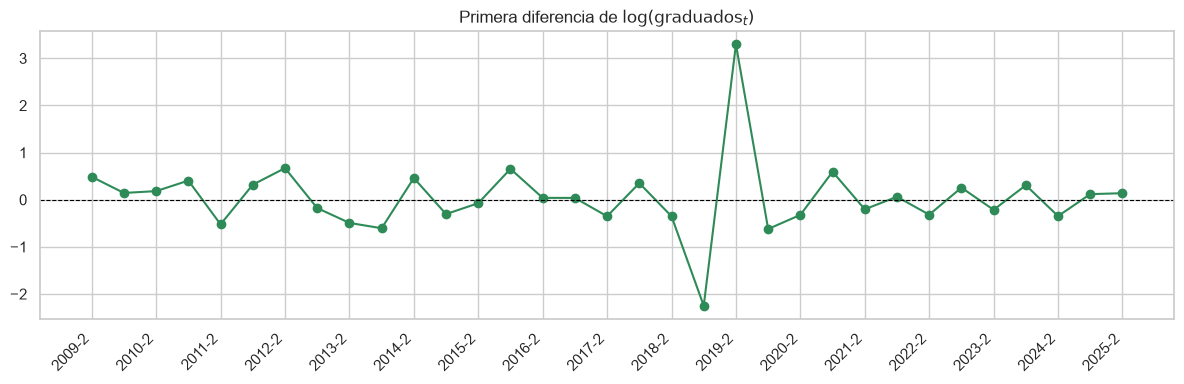

In [22]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(d_log_serie.index, d_log_serie.values, color='seagreen', marker='o')
ax.axhline(0, color='black', lw=0.8, ls='--')
etq_diff = etiquetas.iloc[1:].values
ax.set_xticks(d_log_serie.index[::2])
ax.set_xticklabels(etq_diff[::2], rotation=45, ha='right')
ax.set_title(r'Primera diferencia de $\log(\mathrm{graduados}_t)$')
plt.tight_layout()
plt.savefig('serie_diferenciada.png', dpi=150)
plt.show()

# 5. ACF y PACF con umbral de significancia

Se traza el umbral $\pm 1.96/\sqrt{n}$ (línea roja punteada). La PACF muestra **dos rezagos significativos** (rezago 1 y rezago 2, ambos por debajo del umbral inferior), lo que sugiere una estructura **AR(2)** en la media de $r_t$.

Umbral de significancia al 5%: ±0.3412


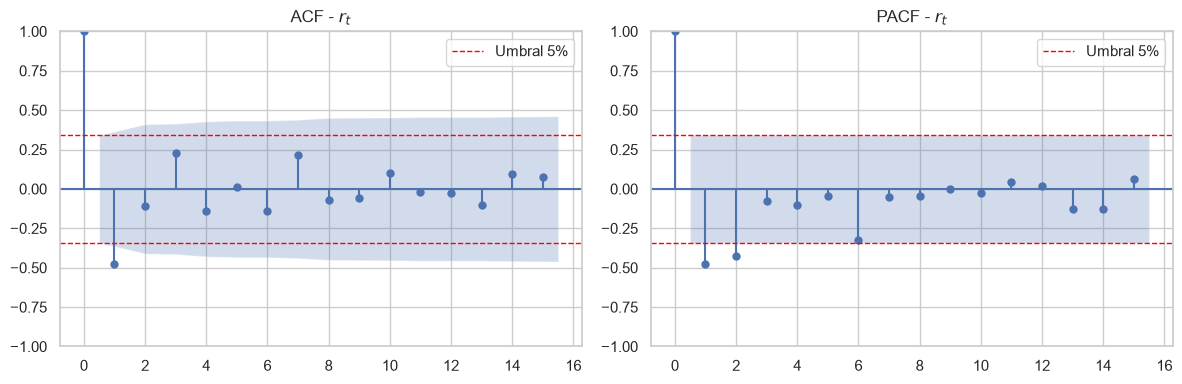

In [23]:
n_d    = len(d_log_serie)
umbral = 1.96 / np.sqrt(n_d)
print(f'Umbral de significancia al 5%: ±{umbral:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(d_log_serie, ax=axes[0], lags=15)
axes[0].axhline( umbral, color='red', ls='--', lw=1, label='Umbral 5%')
axes[0].axhline(-umbral, color='red', ls='--', lw=1)
axes[0].set_title('ACF - $r_t$')
axes[0].legend()

plot_pacf(d_log_serie, ax=axes[1], lags=15, method='ywm')
axes[1].axhline( umbral, color='red', ls='--', lw=1, label='Umbral 5%')
axes[1].axhline(-umbral, color='red', ls='--', lw=1)
axes[1].set_title('PACF - $r_t$')
axes[1].legend()

plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150)
plt.show()

# 6. Prueba de efectos ARCH

Se ajusta un **AR(2)** (consistente con la PACF) sobre $r_t$ y se aplica la prueba ARCH-LM sobre sus residuos.

                               SARIMAX Results                                
Dep. Variable:                  total   No. Observations:                   33
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 -31.321
Date:                Sun, 14 Jun 2026   AIC                             70.643
Time:                        21:18:42   BIC                             76.629
Sample:                             0   HQIC                            72.657
                                 - 33                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0310      0.078      0.399      0.690      -0.121       0.183
ar.L1         -0.6722      0.120     -5.620      0.000      -0.907      -0.438
ar.L2         -0.4184      0.169     -2.478      0.0

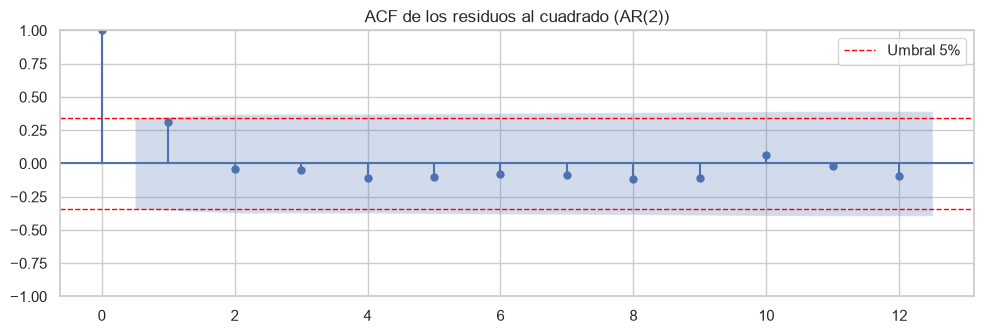

ARCH-LM (4 rezagos): estadístico=3.6875, p-valor=0.4499


In [24]:
# Modelo de referencia: AR(2) sobre r_t
modelo_ar2_ref = ARIMA(d_log_serie, order=(2, 0, 0)).fit()
print(modelo_ar2_ref.summary())

resid_media = modelo_ar2_ref.resid

fig, ax = plt.subplots(figsize=(10, 3.5))
plot_acf(resid_media**2, ax=ax, lags=12)
ax.axhline( umbral, color='red', ls='--', lw=1, label='Umbral 5%')
ax.axhline(-umbral, color='red', ls='--', lw=1)
ax.set_title('ACF de los residuos al cuadrado (AR(2))')
ax.legend()
plt.tight_layout()
plt.show()

lm_stat, lm_p, _, _ = het_arch(resid_media, nlags=4)
print(f'ARCH-LM (4 rezagos): estadístico={lm_stat:.4f}, p-valor={lm_p:.4f}')

# 7. Comparación de modelos: AR(2), MA(1), ARIMA(1,1,1), SARIMA y AR(2)-GARCH(1,1)

Se comparan cinco especificaciones por AIC y BIC. El AR se actualiza a **AR(2)** de acuerdo con la PACF. El GARCH también usa **lags=2** en la ecuación de la media.

In [25]:
resultados_modelos = {}

m_ar2    = ARIMA(log_serie, order=(2, 1, 0)).fit()
resultados_modelos['AR(2) -> ARIMA(2,1,0)'] = (m_ar2.aic, m_ar2.bic, m_ar2)

m_ma     = ARIMA(log_serie, order=(0, 1, 1)).fit()
resultados_modelos['MA(1) -> ARIMA(0,1,1)'] = (m_ma.aic, m_ma.bic, m_ma)

m_arima  = ARIMA(log_serie, order=(1, 1, 1)).fit()
resultados_modelos['ARIMA(1,1,1)'] = (m_arima.aic, m_arima.bic, m_arima)

m_arima211 = ARIMA(log_serie, order=(2, 1, 1)).fit()
resultados_modelos['ARIMA(2,1,1)'] = (m_arima211.aic, m_arima211.bic, m_arima211)

m_sarima = SARIMAX(log_serie, order=(1, 1, 1), seasonal_order=(1, 0, 0, 2),
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
resultados_modelos['SARIMA(1,1,1)(1,0,0)_2'] = (m_sarima.aic, m_sarima.bic, m_sarima)

# GARCH con AR(2) en la media — coherente con la PACF
m_garch_comp = arch_model(d_log_serie, mean='AR', lags=2,
                          vol='GARCH', p=1, q=1, dist='normal').fit(disp='off')
resultados_modelos['AR(2)-GARCH(1,1)'] = (m_garch_comp.aic, m_garch_comp.bic, m_garch_comp)

tabla_comparacion = pd.DataFrame({
    'Modelo': list(resultados_modelos.keys()),
    'AIC':    [v[0] for v in resultados_modelos.values()],
    'BIC':    [v[1] for v in resultados_modelos.values()]
}).sort_values('AIC').reset_index(drop=True)

tabla_comparacion

,Modelo,AIC,BIC
0,"SARIMA(1,1,1)(1,0,0)_2",62.031814,67.636604
1,"MA(1) -> ARIMA(0,1,1)",64.337177,67.330192
2,"AR(2)-GARCH(1,1)",65.212700,73.816623
3,"ARIMA(1,1,1)",66.335705,70.825228
4,"ARIMA(2,1,1)",68.270527,74.256557
5,"AR(2) -> ARIMA(2,1,0)",68.984873,73.474396


In [26]:
mejor = tabla_comparacion.iloc[0]['Modelo']
print(f'Modelo con menor AIC: {mejor}')
print(resultados_modelos[mejor][2].summary())

Modelo con menor AIC: SARIMA(1,1,1)(1,0,0)_2
                                     SARIMAX Results                                      
Dep. Variable:                              total   No. Observations:                   34
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 2)   Log Likelihood                 -27.016
Date:                            Sun, 14 Jun 2026   AIC                             62.032
Time:                                    21:18:42   BIC                             67.637
Sample:                                         0   HQIC                            63.825
                                             - 34                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0580      0.303     -0.192      0.848      -0.652   

# 8. Ajuste del modelo AR(2)-GARCH(1,1)

Se comparan los órdenes GARCH(1,1), GARCH(1,2) y GARCH(2,1) con **AR(2)** en la media. La serie se escala a porcentaje ($\times 100$) para estabilidad numérica del optimizador.

In [27]:
r_pct = 100 * d_log_serie

especificaciones = [(1, 1), (1, 2), (2, 1)]
resultados_garch = []
for p, q in especificaciones:
    am  = arch_model(r_pct, mean='AR', lags=2, vol='GARCH', p=p, q=q, dist='normal')
    res = am.fit(disp='off')
    resultados_garch.append((p, q, res.aic, res.bic, res))
    print(f'AR(2)-GARCH({p},{q}): AIC={res.aic:.3f}  BIC={res.bic:.3f}')

p_sel, q_sel, _, _, modelo_garch = min(resultados_garch, key=lambda x: x[2])
print(f'\nModelo seleccionado: AR(2)-GARCH({p_sel},{q_sel})')
print(modelo_garch.summary())

AR(2)-GARCH(1,1): AIC=351.087  BIC=359.691
AR(2)-GARCH(1,2): AIC=353.087  BIC=363.125
AR(2)-GARCH(2,1): AIC=353.087  BIC=363.125

Modelo seleccionado: AR(2)-GARCH(1,1)
                           AR - GARCH Model Results                           
Dep. Variable:                  total   R-squared:                       0.281
Mean Model:                        AR   Adj. R-squared:                  0.230
Vol Model:                      GARCH   Log-Likelihood:               -169.544
Distribution:                  Normal   AIC:                           351.087
Method:            Maximum Likelihood   BIC:                           359.691
                                        No. Observations:                   31
Date:                Sun, Jun 14 2026   Df Residuals:                       28
Time:                        21:18:42   Df Model:                            3
                               Mean Model                               
                 coef    std err          t     

# 9. Diagnóstico del modelo AR(2)-GARCH(1,1)

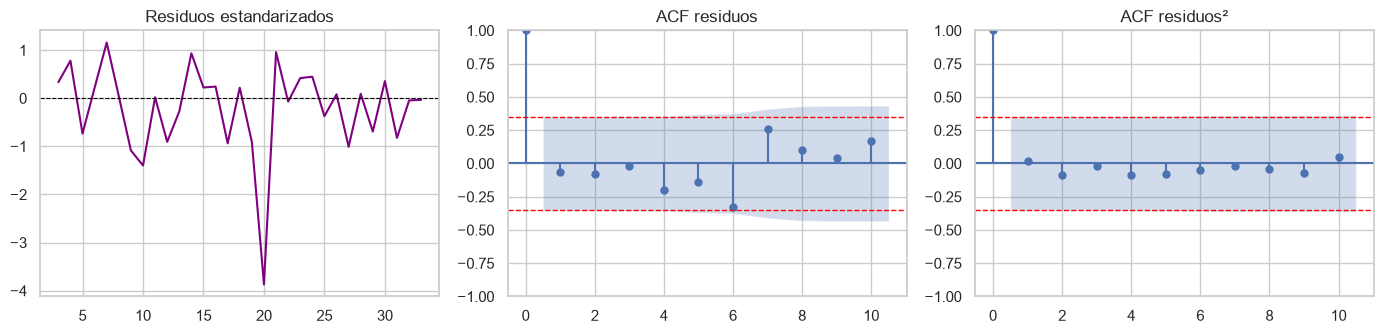

ARCH-LM (residuos estand.): LM=0.4937, p=0.9741
Jarque-Bera: estadístico=53.5017, p=0.0000
Ljung-Box (rezago 8):
    lb_stat  lb_pvalue
8  10.43051     0.2361


In [28]:
std_resid     = modelo_garch.std_resid.dropna()
umbral_resid  = 1.96 / np.sqrt(len(std_resid))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].plot(std_resid.index, std_resid.values, color='purple')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_title('Residuos estandarizados')

plot_acf(std_resid, ax=axes[1], lags=10)
axes[1].axhline( umbral_resid, color='red', ls='--', lw=1)
axes[1].axhline(-umbral_resid, color='red', ls='--', lw=1)
axes[1].set_title('ACF residuos')

plot_acf(std_resid**2, ax=axes[2], lags=10)
axes[2].axhline( umbral_resid, color='red', ls='--', lw=1)
axes[2].axhline(-umbral_resid, color='red', ls='--', lw=1)
axes[2].set_title('ACF residuos²')

plt.tight_layout()
plt.savefig('diagnostico_garch.png', dpi=150)
plt.show()

lm2, lmp2, _, _ = het_arch(std_resid, nlags=4)
jb,  jbp        = stats.jarque_bera(std_resid)
lb              = sm.stats.acorr_ljungbox(std_resid, lags=[8], return_df=True)

print(f'ARCH-LM (residuos estand.): LM={lm2:.4f}, p={lmp2:.4f}')
print(f'Jarque-Bera: estadístico={jb:.4f}, p={jbp:.4f}')
print('Ljung-Box (rezago 8):')
print(lb)

# 10. Pronóstico para los próximos 4 semestres

Se reconstruye el nivel pronosticado con la transformación inversa:
$$\widehat{\text{graduados}}_{T+h} = \exp\!\left(y_T + \sum_{i=1}^{h}\hat r_{T+i}\right)$$
Los intervalos al 95% se construyen como $\exp(\log\hat y \pm 1.96\,\hat\sigma_{\text{acum}})$, donde $\hat\sigma_{\text{acum}} = \sqrt{\sum_{i=1}^{h}\widehat{\text{Var}}(r_{T+i})}$ en escala logarítmica.

In [29]:
h    = 4
pron = modelo_garch.forecast(horizon=h, reindex=False)

# Verificación de escala
print('Media pronosticada por horizonte (% → log):')
print(pron.mean.iloc[-1])
print('Varianza pronosticada (% → log):')
print(pron.variance.iloc[-1])

media_pron = pron.mean.iloc[-1] / 100        # escala log
var_pron   = pron.variance.iloc[-1] / 1e4    # escala log

ultimo_log = log_serie.iloc[-1]
log_pron   = ultimo_log + media_pron.cumsum().values
se_acum    = np.sqrt(np.cumsum(var_pron.values))

graduados_pron = np.exp(log_pron)
lim_inf        = np.exp(log_pron - 1.96 * se_acum)
lim_sup        = np.exp(log_pron + 1.96 * se_acum)

# Etiquetas futuras (S = 1 o 2 únicamente)
ultimo_anio = int(data['year'].iloc[-1])
ultimo_sem  = int(data['period'].iloc[-1])
print(f'\nÚltimo periodo observado: {etiquetas.iloc[-1]}, log={ultimo_log:.4f}')

etiquetas_futuras = []
anio, sem = ultimo_anio, ultimo_sem
for _ in range(h):
    if sem == 1:
        sem = 2
    else:
        sem  = 1
        anio += 1
    etiquetas_futuras.append(f'{anio}-{sem}')

tabla_pron = pd.DataFrame({
    'periodo':                 etiquetas_futuras,
    'graduados_pronosticados': np.round(graduados_pron, 1),
    'limite_inferior_95':      np.round(lim_inf, 1),
    'limite_superior_95':      np.round(lim_sup, 1)
})
tabla_pron

Media pronosticada por horizonte (% → log):
h.1    2.666504
h.2    5.983033
h.3    7.686879
h.4    6.254198
Name: 33, dtype: float64
Varianza pronosticada (% → log):
h.1    2004.833209
h.2    4244.966161
h.3    6522.363734
h.4    8836.198511
Name: 33, dtype: float64

Último periodo observado: 2025-2, log=3.4340


,periodo,graduados_pronosticados,limite_inferior_95,limite_superior_95
0,2026-1,31.8,13.2,76.6
1,2026-2,33.8,7.2,159.2
2,2027-1,36.5,4.0,334.4
3,2027-2,38.9,2.2,693.0


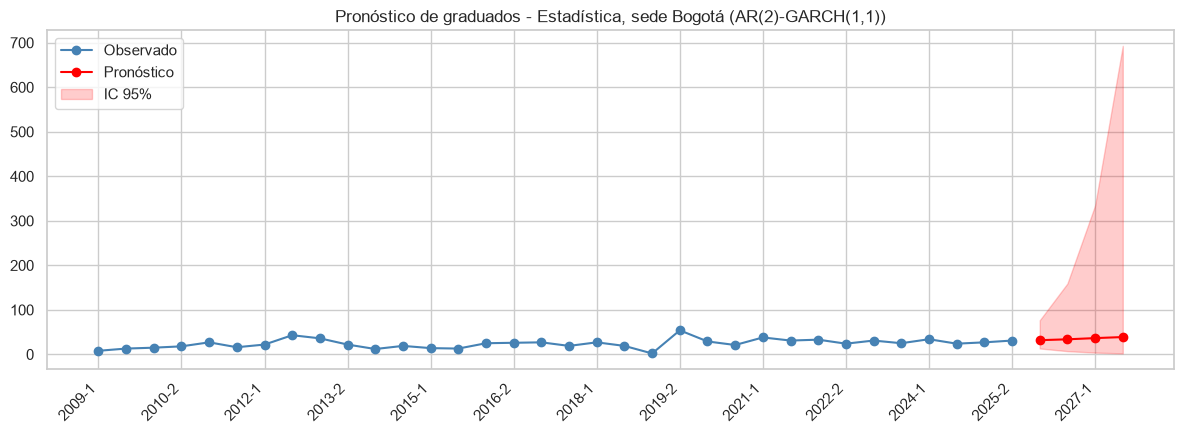

In [30]:
idx_futuro = np.arange(serie.index[-1] + 1, serie.index[-1] + 1 + h)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(serie.index, serie.values, marker='o', color='steelblue', label='Observado')
ax.plot(idx_futuro, graduados_pron, marker='o', color='red', label='Pronóstico')
ax.fill_between(idx_futuro, lim_inf, lim_sup, color='red', alpha=0.2, label='IC 95%')

todas_etiquetas = list(etiquetas.values) + etiquetas_futuras
todos_idx       = list(serie.index) + list(idx_futuro)
ax.set_xticks(todos_idx[::3])
ax.set_xticklabels([todas_etiquetas[i] for i in range(0, len(todas_etiquetas), 3)],
                   rotation=45, ha='right')
ax.set_title('Pronóstico de graduados - Estadística, sede Bogotá (AR(2)-GARCH(1,1))')
ax.legend()
plt.tight_layout()
plt.savefig('pronostico_garch.png', dpi=150)
plt.show()